# Location Entropy Analysis 


## Methodology Overview

0. Explore raw trace schema and columns
1. Load and normalize Cabspotting traces
2. Assign discrete location cells
3. Compute time-weighted location probabilities
4. Calculate per-user location entropy
5. Export ranked results
6. Generate explanatory visualizations

## Why This Approach

The core design choice in this implementation is to treat a user's location probability as a **time-weighted share of observed dwell time** rather than a simple count of GPS points. That makes the resulting entropy metric better aligned with mobility behavior, because spending two hours in one place should matter more than briefly passing through it. The workflow is also broken into small, production-friendly steps so that data loading, discretization, probability estimation, entropy calculation, and reporting can each be tested or replaced independently.

In [45]:
import csv
import math
import statistics
from collections import defaultdict
from dataclasses import dataclass, replace
from datetime import datetime, timezone
from pathlib import Path

from IPython.display import display
import pandas as pd
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "cabspottingdata"
GRID_SIZE_DEGREES = 0.005
MAX_GAP_SECONDS = 10800
LIMIT_USERS = None  # Set to None to process the full dataset.
TRAJECTORY_POINT_LIMIT = 1000
OUTPUT_CSV = PROJECT_ROOT / "outputs" / "stepwise_location_entropy_results.csv"

## Step 0: Explore Raw Data Schema

This step inspects one raw Cabspotting trace file to confirm the row layout before full loading.

### Code Explanation

The code locates a sample `new_*.txt` file, reads the first few non-empty rows, and maps those fields to the raw column names.

### Why This Matters

Cabspotting trace files do not include header rows, so making the expected columns explicit helps prevent schema mistakes later in parsing and type conversion.

### How to Read the Output

You should see the raw columns (`latitude`, `longitude`, `occupancy`, `timestamp`), the detected field count, and a small preview table from the sample file. The later entropy analysis uses `latitude`, `longitude`, and `timestamp`.


In [46]:
SCHEMA_COLUMNS = ["latitude", "longitude", "occupancy", "timestamp"]

trace_files = sorted(DATA_DIR.glob("new_*.txt"))
sample_file = trace_files[0]
preview_rows = []
with sample_file.open("r", encoding="utf-8") as source:
    for line in source:
        stripped_line = line.strip()
        if not stripped_line:
            continue
        preview_rows.append(stripped_line.split())
        if len(preview_rows) == 5:
            break

sample_field_count = len(preview_rows[0]) if preview_rows else 0

print(f"Trace files found: {len(trace_files):,}")
print(f"Detected columns in sample row: {sample_field_count}")

preview_df = pd.DataFrame(preview_rows, columns=SCHEMA_COLUMNS)
display(preview_df)

Trace files found: 536
Detected columns in sample row: 4


,latitude,longitude,occupancy,timestamp
0,37.75134,-122.39488,0,1213084687
1,37.75136,-122.39527,0,1213084659
2,37.75199,-122.3946,0,1213084540
3,37.7508,-122.39346,0,1213084489
4,37.75015,-122.39256,0,1213084237


## Step 1: Load and Normalize Traces

This step defines the base data structures and implements raw Cabspotting file loading, row parsing, and timestamp sorting.

### Code Explanation

The notebook starts by turning each raw text file into a `UserTrace` composed of validated `TracePoint` records. During parsing, malformed rows are skipped rather than crashing the full run, and each user's records are sorted into ascending timestamp order. This keeps downstream logic simple.

### Why This Matters

Entropy only makes sense if the temporal order is correct, because later steps estimate time spent between consecutive observations. If traces are unsorted or malformed rows are left unchecked, the probability calculation can be distorted by negative or invalid durations.


In [47]:
@dataclass(frozen=True, slots=True)
class TracePoint:
    """One parsed Cabspotting GPS observation for a single user."""

    user_id: str
    latitude: float
    longitude: float
    timestamp: int
    location_id: str | None = None


@dataclass(frozen=True, slots=True)
class UserTrace:
    """All normalized observations belonging to one user trace file."""

    user_id: str
    records: list[TracePoint]


@dataclass(frozen=True, slots=True)
class DatasetLoadResult:
    """Dataset loading output plus summary statistics for validation."""

    traces: list[UserTrace]
    files_seen: int
    rows_loaded: int
    rows_skipped: int


def iter_trace_files(data_dir: Path) -> list[Path]:
    """Return all Cabspotting trace files in deterministic filename order."""

    trace_files = sorted(data_dir.glob("new_*.txt"))
    if not trace_files:
        raise FileNotFoundError(f"No Cabspotting trace files found in {data_dir}.")
    return trace_files


def parse_trace_line(raw_line: str, user_id: str) -> TracePoint:
    """Parse one raw trace row into a `TracePoint`."""

    parts = raw_line.split()
    if len(parts) != 4:
        raise ValueError("Expected 4 columns")

    return TracePoint(
        user_id=user_id,
        latitude=float(parts[0]),
        longitude=float(parts[1]),
        timestamp=int(parts[3]),
    )


def load_user_trace(file_path: Path) -> tuple[UserTrace, int]:
    """Load one user file, skip malformed rows, and sort by ascending time."""

    user_id = file_path.stem.removeprefix("new_")
    records: list[TracePoint] = []
    skipped_rows = 0

    for raw_line in file_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue

        try:
            record = parse_trace_line(line, user_id)
        except ValueError:
            skipped_rows += 1
            continue

        records.append(record)

    records.sort(key=lambda record: record.timestamp)
    return UserTrace(user_id=user_id, records=records), skipped_rows


def load_dataset(data_dir: Path, limit_users: int | None = None) -> DatasetLoadResult:
    """Load multiple user traces and aggregate dataset-level row counts."""

    trace_files = iter_trace_files(data_dir)
    if limit_users is not None:
        trace_files = trace_files[:limit_users]

    traces: list[UserTrace] = []
    rows_loaded = 0
    rows_skipped = 0

    for file_path in trace_files:
        trace, skipped_rows = load_user_trace(file_path)
        traces.append(trace)
        rows_loaded += len(trace.records)
        rows_skipped += skipped_rows

    return DatasetLoadResult(
        traces=traces,
        files_seen=len(trace_files),
        rows_loaded=rows_loaded,
        rows_skipped=rows_skipped,
    )

In [48]:
result = load_dataset(DATA_DIR, limit_users=LIMIT_USERS)
total_raw_rows = result.rows_loaded + result.rows_skipped

print("Step 1 complete: load and normalize traces")
print(f"Users loaded: {len(result.traces)}")
print(f"Trace files processed: {result.files_seen}")
print(f"Total raw rows in dataset: {total_raw_rows:,}")
print(f"Rows loaded: {result.rows_loaded}")
print(f"Rows skipped: {result.rows_skipped}")

Step 1 complete: load and normalize traces
Users loaded: 536
Trace files processed: 536
Total raw rows in dataset: 11,219,955
Rows loaded: 11219955
Rows skipped: 0


## Step 2: Assign Discrete Location Cells

This step introduces a deterministic grid-based location ID so continuous GPS coordinates can be converted into reusable discrete locations.

### Code Explanation

Each latitude/longitude pair is mapped into a grid cell using a fixed degree-based resolution. The result is a stable `location_id` that can be counted and compared across records without requiring an external geospatial index.

### Why This Matters

Entropy works by comparing probabilities across distinct locations. Raw GPS gives almost-unique coordinates at each timestamp, so if we use them directly, nearly every point looks like a different place. That makes location counts unstable and can falsely inflate movement diversity. Grid cells solve this by grouping nearby coordinates into the same location.


In [49]:
def build_location_id(latitude: float, longitude: float, grid_size_degrees: float) -> str:
    """Convert one latitude/longitude pair into a deterministic grid cell ID."""

    if grid_size_degrees <= 0:
        raise ValueError("grid_size_degrees must be greater than zero.")

    lat_index = math.floor(latitude / grid_size_degrees)
    lon_index = math.floor(longitude / grid_size_degrees)
    return f"grid:{grid_size_degrees:.6f}:{lat_index}:{lon_index}"


def assign_locations_to_trace(trace: UserTrace, grid_size_degrees: float) -> UserTrace:
    """Assign a discrete grid cell ID to every record in one user trace."""

    records_with_locations = [
        replace(
            record,
            location_id=build_location_id(
                record.latitude, record.longitude, grid_size_degrees
            ),
        )
        for record in trace.records
    ]
    return UserTrace(user_id=trace.user_id, records=records_with_locations)


def assign_locations(result: DatasetLoadResult, grid_size_degrees: float) -> DatasetLoadResult:
    """Assign discrete location IDs across all loaded traces."""

    traces_with_locations = [
        assign_locations_to_trace(trace, grid_size_degrees) for trace in result.traces
    ]
    return DatasetLoadResult(
        traces=traces_with_locations,
        files_seen=result.files_seen,
        rows_loaded=result.rows_loaded,
        rows_skipped=result.rows_skipped,
    )

In [50]:
result = assign_locations(result, grid_size_degrees=GRID_SIZE_DEGREES)
unique_locations = {
    record.location_id
    for trace in result.traces
    for record in trace.records
    if record.location_id is not None
}

print("Step 2 complete: assign discrete location cells")
print(f"Grid size (degrees): {GRID_SIZE_DEGREES}")
print(f"Unique location cells: {len(unique_locations)}")

Step 2 complete: assign discrete location cells
Grid size (degrees): 0.005
Unique location cells: 6161


## Step 3: Compute Time-Weighted Location Probabilities

This step converts each trace into time spent per location and then normalizes that dwell time into `p(i)` for each user.

### Code Explanation

For every pair of consecutive observations, the notebook attributes the elapsed time to the earlier location. These dwell times are accumulated per location and then divided by the user's total valid observed time to produce a probability distribution that sums to `1.0`. Large gaps above `MAX_GAP_SECONDS` are excluded so that long unobserved periods do not artificially inflate dwell time.

### Why This Matters

This is the key modeling choice in the notebook. Counting raw GPS points would over-weight users who are sampled more frequently, while time-weighting better captures how a user actually allocates time across locations. The gap filter is equally important because Cabspotting traces can contain long intervals where the taxi is simply not observed.


In [51]:
@dataclass(frozen=True, slots=True)
class UserLocationProfile:
    """Time-weighted location distribution for one user."""

    user_id: str
    dwell_seconds_by_location: dict[str, int]
    location_probabilities: dict[str, float]
    total_observed_seconds: int
    transitions_used: int
    transitions_skipped: int


@dataclass(frozen=True, slots=True)
class ProbabilityComputationResult:
    """Dataset-level output for time-weighted location probabilities."""

    user_profiles: list[UserLocationProfile]
    total_observed_seconds: int
    transitions_used: int
    transitions_skipped: int


def normalize_gap_limit(max_gap_seconds: int) -> int | None:
    """Normalize the gap limit into an internal optional value."""

    return None if max_gap_seconds <= 0 else max_gap_seconds


def compute_trace_location_profile(trace: UserTrace, max_gap_seconds: int | None) -> UserLocationProfile:
    """Compute dwell-time location probabilities for one user trace."""

    dwell_seconds_by_location: defaultdict[str, int] = defaultdict(int)
    transitions_used = 0
    transitions_skipped = 0

    for current_record, next_record in zip(trace.records, trace.records[1:]):
        if current_record.location_id is None:
            raise ValueError(
                f"Trace '{trace.user_id}' is missing location IDs. Run location assignment first."
            )

        duration_seconds = next_record.timestamp - current_record.timestamp
        if duration_seconds <= 0:
            transitions_skipped += 1
            continue

        if max_gap_seconds is not None and duration_seconds > max_gap_seconds:
            transitions_skipped += 1
            continue

        dwell_seconds_by_location[current_record.location_id] += duration_seconds
        transitions_used += 1

    total_observed_seconds = sum(dwell_seconds_by_location.values())
    location_probabilities = (
        {
            location_id: dwell_seconds / total_observed_seconds
            for location_id, dwell_seconds in dwell_seconds_by_location.items()
        }
        if total_observed_seconds > 0
        else {}
    )

    return UserLocationProfile(
        user_id=trace.user_id,
        dwell_seconds_by_location=dict(dwell_seconds_by_location),
        location_probabilities=location_probabilities,
        total_observed_seconds=total_observed_seconds,
        transitions_used=transitions_used,
        transitions_skipped=transitions_skipped,
    )


def compute_location_probabilities(result: DatasetLoadResult, max_gap_seconds: int | None) -> ProbabilityComputationResult:
    """Compute time-weighted location probabilities across all loaded traces."""

    user_profiles = [
        compute_trace_location_profile(trace, max_gap_seconds)
        for trace in result.traces
    ]
    return ProbabilityComputationResult(
        user_profiles=user_profiles,
        total_observed_seconds=sum(
            profile.total_observed_seconds for profile in user_profiles
        ),
        transitions_used=sum(profile.transitions_used for profile in user_profiles),
        transitions_skipped=sum(profile.transitions_skipped for profile in user_profiles),
    )

In [52]:
max_gap_seconds = normalize_gap_limit(MAX_GAP_SECONDS)
probabilities = compute_location_probabilities(result, max_gap_seconds)

print("Step 3 complete: compute time-weighted location probabilities")
print(f"Max gap filter (seconds): {max_gap_seconds if max_gap_seconds is not None else 'disabled'}")
print(f"Observed seconds used: {probabilities.total_observed_seconds}")
print(f"Transitions used: {probabilities.transitions_used}")
print(f"Transitions skipped: {probabilities.transitions_skipped}")

Step 3 complete: compute time-weighted location probabilities
Max gap filter (seconds): 10800
Observed seconds used: 783295885
Transitions used: 11210955
Transitions skipped: 8464


## Step 4: Calculate Per-User Location Entropy

This step applies the Shannon entropy formula to the time-weighted location probabilities.

### Code Explanation

For each user, the notebook computes Shannon entropy in bits using `E = -sum(p(i) * log2(p(i)))`. It also derives a normalized entropy score in `[0, 1]`, the number of non-zero locations, and the share of the user's most dominant location.

### Why This Matters

The raw entropy value captures how unpredictable or diffuse a user's movement pattern is. Low entropy means most observed time is concentrated in one or a few places, while high entropy means time is spread more evenly across many places. The normalized version is useful because it makes users with different numbers of visited locations easier to compare.


In [53]:
def calculate_entropy(location_probabilities: dict[str, float]) -> float:
    """Calculate Shannon entropy from a location probability distribution."""

    return -sum(
        probability * math.log2(probability)
        for probability in location_probabilities.values()
        if probability > 0
    )


def compute_entropy_metrics(probabilities: ProbabilityComputationResult) -> dict[str, float | list[dict[str, float | int | str]]]:
    """Compute per-user and dataset-level entropy metrics."""

    user_metrics: list[dict[str, float | int | str]] = []

    for profile in probabilities.user_profiles:
        entropy = calculate_entropy(profile.location_probabilities)
        num_locations = len(profile.location_probabilities)
        max_possible_entropy = math.log2(num_locations) if num_locations > 1 else 0.0
        normalized_entropy = entropy / max_possible_entropy if max_possible_entropy > 0 else 0.0
        top_location_share = (
            max(profile.location_probabilities.values())
            if profile.location_probabilities
            else 0.0
        )
        user_metrics.append(
            {
                "user_id": profile.user_id,
                "entropy": entropy,
                "normalized_entropy": normalized_entropy,
                "num_locations": num_locations,
                "top_location_share": top_location_share,
            }
        )

    if not user_metrics:
        return {
            "user_metrics": [],
            "mean_entropy": 0.0,
            "min_entropy": 0.0,
            "max_entropy": 0.0,
        }

    entropy_values = [metric["entropy"] for metric in user_metrics]
    return {
        "user_metrics": user_metrics,
        "mean_entropy": sum(entropy_values) / len(entropy_values),
        "min_entropy": min(entropy_values),
        "max_entropy": max(entropy_values),
    }

In [54]:
entropy_metrics = compute_entropy_metrics(probabilities)

print("Step 4 complete: calculate per-user location entropy")
print(f"Mean entropy: {entropy_metrics['mean_entropy']:.4f}")
print(f"Min entropy: {entropy_metrics['min_entropy']:.4f}")
print(f"Max entropy: {entropy_metrics['max_entropy']:.4f}")

Step 4 complete: calculate per-user location entropy
Mean entropy: 7.0656
Min entropy: 0.5618
Max entropy: 7.8468


## Step 5: Export Ranked Results

This step flattens the per-user metrics into an analysis-friendly result table and writes it to CSV.

### Code Explanation

The notebook merges the probability outputs and entropy outputs into one row per user, then ranks users by descending entropy before exporting the results to CSV. The exported table includes entropy, normalized entropy, number of locations, top-location share, observed time, and transition counts.

### Why This Matters

A flat result table is useful for both analysis and production handoff. It creates a simple contract for downstream consumers such as dashboards, experiments, or batch scoring jobs, and it makes the notebook results easy to audit outside the notebook itself.


In [55]:
def build_user_result_rows(
    probabilities: ProbabilityComputationResult,
    entropy_metrics: dict[str, float | list[dict[str, float | int | str]]],
) -> list[dict[str, float | int | str]]:
    """Build flattened result rows by combining probability and entropy outputs."""

    probability_by_user = {
        profile.user_id: profile for profile in probabilities.user_profiles
    }
    result_rows: list[dict[str, float | int | str]] = []

    for entropy_metric in entropy_metrics["user_metrics"]:
        probability_profile = probability_by_user[entropy_metric["user_id"]]
        result_rows.append(
            {
                "user_id": entropy_metric["user_id"],
                "entropy": entropy_metric["entropy"],
                "normalized_entropy": entropy_metric["normalized_entropy"],
                "num_locations": entropy_metric["num_locations"],
                "top_location_share": entropy_metric["top_location_share"],
                "total_observed_seconds": probability_profile.total_observed_seconds,
                "transitions_used": probability_profile.transitions_used,
                "transitions_skipped": probability_profile.transitions_skipped,
            }
        )

    return result_rows


def export_result_rows(rows: list[dict[str, float | int | str]], output_path: Path) -> int:
    """Write flattened per-user result rows to a CSV file."""

    output_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = [
        "rank",
        "user_id",
        "entropy",
        "normalized_entropy",
        "num_locations",
        "top_location_share",
        "total_observed_seconds",
        "transitions_used",
        "transitions_skipped",
    ]

    with output_path.open("w", newline="", encoding="utf-8") as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
        writer.writeheader()
        for rank, row in enumerate(rows, start=1):
            writer.writerow(
                {
                    "rank": rank,
                    "user_id": row["user_id"],
                    "entropy": f"{row['entropy']:.8f}",
                    "normalized_entropy": f"{row['normalized_entropy']:.8f}",
                    "num_locations": row["num_locations"],
                    "top_location_share": f"{row['top_location_share']:.8f}",
                    "total_observed_seconds": row["total_observed_seconds"],
                    "transitions_used": row["transitions_used"],
                    "transitions_skipped": row["transitions_skipped"],
                }
            )

    return len(rows)

In [56]:
result_rows = build_user_result_rows(probabilities, entropy_metrics)
rows_sorted = sorted(result_rows, key=lambda row: row["entropy"], reverse=True)
rows_exported = export_result_rows(rows_sorted, OUTPUT_CSV)

print("Step 5 complete: export ranked results")
print(f"CSV export: {OUTPUT_CSV}")
print(f"Rows exported: {rows_exported}")

Step 5 complete: export ranked results
CSV export: c:\Users\HP\OneDrive\Documents\GitHub\location_entropy\outputs\stepwise_location_entropy_results.csv
Rows exported: 536


## Step 6: Generate Visualizations

This step focuses on visualising the findings of this assessment: the overall entropy distribution, the relationship between entropy and number of observed locations, representative GPS point density maps, interactive representative single-day 3D trajectories, and a simple segment-level summary.


### Analytical Purpose

This step is where the notebook shifts from implementation to interpretation. Instead of showing only that the entropy function runs, the plots test whether the metric behaves in a way that matches intuition: routine users should look spatially concentrated and probability-dominated by a few locations, while exploratory users should look more distributed.

### How to Interpret the Graphs

- **Entropy distribution:** Users on the left are more routine and concentrated in a few places; users on the right spread their observed time more evenly across locations.
- **Entropy vs. number of observed locations:** Each dot is one user. Moving right means the user was observed in more locations, moving up means their time is spread more evenly across those locations, the color shows the share of the user's time spent in the dominant location, and larger dots mean more observed time.
- **Representative GPS point density maps:** Brighter areas show where sampled GPS records are more concentrated for that user. This is a point-density view, not an exact dwell-time calculation.
- **Interactive representative single-day 3D trajectories:** Each figure shows one representative user's day with the most observed time under the gap-filter rule. Longitude and latitude show where the user moved, height shows the recorded hour of day, and you can rotate or zoom to inspect the trajectory more closely. The green marker shows the start point and the red marker shows the end point. Hovering over points shows the recorded timestamp.
- **Segment summary table:** This aggregates users into low-, medium-, and high-entropy groups to show how the number of locations, top-location dominance, and observed time change across segments.


In [57]:
# Step 6 helper functions for the visualization cells below.
def downsample_trace_records(records: list[TracePoint], max_points: int) -> list[TracePoint]:
    """Downsample trace records so trajectory plots remain readable."""

    if max_points <= 0 or len(records) <= max_points:
        return records
    if max_points == 1:
        return [records[0]]

    last_index = len(records) - 1
    sample_indices = sorted(
        {
            math.floor(index * last_index / (max_points - 1))
            for index in range(max_points)
        }
    )
    return [records[index] for index in sample_indices]


def select_representative_day_records(
    records: list[TracePoint], max_gap_seconds: int | None
) -> tuple[str, list[TracePoint]]:
    """Select the day with the most observed seconds from one user's trace."""

    if not records:
        return "n/a", []

    records_by_day: defaultdict[str, list[TracePoint]] = defaultdict(list)
    observed_seconds_by_day: defaultdict[str, int] = defaultdict(int)

    for record in records:
        day = datetime.fromtimestamp(record.timestamp, tz=timezone.utc).date().isoformat()
        records_by_day[day].append(record)

    for current_record, next_record in zip(records, records[1:]):
        current_day = datetime.fromtimestamp(
            current_record.timestamp, tz=timezone.utc
        ).date().isoformat()
        next_day = datetime.fromtimestamp(
            next_record.timestamp, tz=timezone.utc
        ).date().isoformat()
        gap_seconds = next_record.timestamp - current_record.timestamp

        if gap_seconds <= 0:
            continue
        if max_gap_seconds is not None and gap_seconds > max_gap_seconds:
            continue
        if current_day != next_day:
            continue

        observed_seconds_by_day[current_day] += gap_seconds

    best_day = max(
        records_by_day,
        key=lambda day: (observed_seconds_by_day[day], len(records_by_day[day])),
    )
    return best_day, records_by_day[best_day]



In [58]:
# Step 6 setup: shared preparation for all graphs below.
import matplotlib.pyplot as plt

ranked_rows_for_visuals = list(reversed(rows_sorted))
trace_lookup = {trace.user_id: trace for trace in result.traces}
representative_labels = ["Low entropy example", "Median entropy example", "High entropy example"]

segment_names = ["Low entropy", "Medium entropy", "High entropy"]
segment_buckets = {segment_name: [] for segment_name in segment_names}
for index, row in enumerate(ranked_rows_for_visuals):
    bucket_index = min(len(segment_names) - 1, index * len(segment_names) // len(ranked_rows_for_visuals))
    segment_buckets[segment_names[bucket_index]].append(row)

representative_indices = (
    sorted({0, len(ranked_rows_for_visuals) // 2, len(ranked_rows_for_visuals) - 1})
    if ranked_rows_for_visuals
    else []
)
representative_rows = [ranked_rows_for_visuals[index] for index in representative_indices]
representative_user_ids = [row["user_id"] for row in representative_rows]

segment_summary = []
for segment_name in segment_names:
    bucket = segment_buckets[segment_name]
    if not bucket:
        continue
    segment_summary.append(
        {
            "segment": segment_name,
            "user_count": len(bucket),
            "avg_entropy": sum(row["entropy"] for row in bucket) / len(bucket),
            "avg_num_locations": sum(row["num_locations"] for row in bucket) / len(bucket),
            "avg_top_location_share": sum(row["top_location_share"] for row in bucket) / len(bucket),
            "avg_observed_hours": sum(row["total_observed_seconds"] for row in bucket) / 3600 / len(bucket),
        }
    )

entropy_values = [row["entropy"] for row in rows_sorted]
median_entropy = statistics.median(entropy_values) if entropy_values else 0.0
mean_entropy = sum(entropy_values) / len(entropy_values) if entropy_values else 0.0
step6_matplotlib_figures = []
step6_plotly_figures = []
segment_summary_df = None

In [59]:
# Graph 1: Distribution of location entropy across users.
figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(
    entropy_values,
    bins=min(30, max(5, len(entropy_values))),
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)
axis.axvline(
    mean_entropy,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_entropy:.2f}",
)
axis.axvline(
    median_entropy,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_entropy:.2f}",
)
axis.set_title("Location Entropy Distribution")
axis.set_xlabel("Entropy (bits)")
axis.set_ylabel("User count")
axis.legend()
figure.tight_layout()
step6_matplotlib_figures.append(figure)
plt.close(figure)

In [60]:
# Graph 2: Entropy versus number of observed locations.
x_values = [max(1, row["num_locations"]) for row in result_rows]
figure, axis = plt.subplots(figsize=(10, 6))
scatter = axis.scatter(
    x_values,
    [row["entropy"] for row in result_rows],
    c=[row["top_location_share"] for row in result_rows],
    s=[max(40, min(320, row["total_observed_seconds"] / 300)) for row in result_rows],
    cmap="viridis_r",
    alpha=0.8,
    edgecolors="black",
    linewidths=0.4,
)
for row in representative_rows:
    axis.annotate(
        row["user_id"],
        (max(1, row["num_locations"]), row["entropy"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )
axis.set_title("Entropy vs. Number of Observed Locations")
axis.set_xlabel("Number of observed locations")
axis.set_ylabel("Entropy (bits)")
colorbar = figure.colorbar(scatter, ax=axis)
colorbar.set_label("Share of user's time spent in the dominant location")
figure.tight_layout()
step6_matplotlib_figures.append(figure)
plt.close(figure)

In [61]:
# Graph 3: Representative GPS point density maps.
if representative_rows:
    figure, axes = plt.subplots(
        1,
        len(representative_rows),
        figsize=(6 * len(representative_rows), 5),
        squeeze=False,
    )
    for axis, row, example_label in zip(axes[0], representative_rows, representative_labels):
        trace = trace_lookup[row["user_id"]]
        sampled_records = downsample_trace_records(
            trace.records,
            TRAJECTORY_POINT_LIMIT * 4,
        )
        hexbin = axis.hexbin(
            [record.longitude for record in sampled_records],
            [record.latitude for record in sampled_records],
            gridsize=35,
            cmap="magma",
            mincnt=1,
        )
        axis.set_title(
            f"{example_label}\nUser {row['user_id']} | locations={row['num_locations']}"
        )
        axis.set_xlabel("Longitude")
        axis.set_ylabel("Latitude")
        figure.colorbar(hexbin, ax=axis, label="GPS points per hexbin (downsampled)")
    figure.suptitle("Representative GPS Point Density Maps", y=1.02)
    figure.tight_layout()
    step6_matplotlib_figures.append(figure)
    plt.close(figure)

In [62]:
# Graph 4: Interactive single-day 3D representative trajectories.
# Table: Entropy segment summary.
if representative_rows:
    step6_plotly_figures = []
    for row, example_label in zip(representative_rows, representative_labels):
        trace = trace_lookup[row["user_id"]]
        representative_day, day_records = select_representative_day_records(
            trace.records, max_gap_seconds
        )
        sampled_records = downsample_trace_records(day_records, TRAJECTORY_POINT_LIMIT)
        plotly_figure = go.Figure()

        if sampled_records:
            point_data = []
            for record in sampled_records:
                moment = datetime.fromtimestamp(record.timestamp, tz=timezone.utc)
                point_data.append(
                    {
                        "longitude": record.longitude,
                        "latitude": record.latitude,
                        "hour_of_day": moment.hour + moment.minute / 60 + moment.second / 3600,
                        "timestamp_label": moment.strftime("%Y-%m-%d %H:%M:%S UTC"),
                    }
                )

            marker_config = {
                "size": 3,
                "color": [point["hour_of_day"] for point in point_data],
                "colorscale": "Viridis",
                "showscale": True,
                "colorbar": {
                    "title": "Hour of day",
                    "len": 0.75,
                },
            }

            plotly_figure.add_trace(
                go.Scatter3d(
                    x=[point["longitude"] for point in point_data],
                    y=[point["latitude"] for point in point_data],
                    z=[point["hour_of_day"] for point in point_data],
                    mode="lines+markers",
                    line={"color": "steelblue", "width": 4},
                    marker=marker_config,
                    text=[point["timestamp_label"] for point in point_data],
                    hovertemplate=(
                        "Longitude: %{x:.4f}<br>"
                        "Latitude: %{y:.4f}<br>"
                        "Hour of day: %{z:.2f}<br>"
                        "Timestamp: %{text}<extra></extra>"
                    ),
                    name=f"{example_label} ({row['user_id']})",
                    showlegend=False,
                )
            )
            if len(point_data) == 1:
                only_point = point_data[0]
                plotly_figure.add_trace(
                    go.Scatter3d(
                        x=[only_point["longitude"]],
                        y=[only_point["latitude"]],
                        z=[only_point["hour_of_day"]],
                        mode="markers",
                        marker={"size": 10, "color": "darkorange"},
                        text=[only_point["timestamp_label"]],
                        hovertemplate=(
                            "Only recorded point<br>"
                            "Longitude: %{x:.4f}<br>"
                            "Latitude: %{y:.4f}<br>"
                            "Hour of day: %{z:.2f}<br>"
                            "Timestamp: %{text}<extra></extra>"
                        ),
                        name="Only recorded point",
                        showlegend=True,
                    )
                )
            else:
                start_point = point_data[0]
                end_point = point_data[-1]
                plotly_figure.add_trace(
                    go.Scatter3d(
                        x=[start_point["longitude"]],
                        y=[start_point["latitude"]],
                        z=[start_point["hour_of_day"]],
                        mode="markers",
                        marker={"size": 9, "color": "limegreen"},
                        text=[start_point["timestamp_label"]],
                        hovertemplate=(
                            "Start point<br>"
                            "Longitude: %{x:.4f}<br>"
                            "Latitude: %{y:.4f}<br>"
                            "Hour of day: %{z:.2f}<br>"
                            "Timestamp: %{text}<extra></extra>"
                        ),
                        name="Start point",
                        showlegend=True,
                    )
                )
                plotly_figure.add_trace(
                    go.Scatter3d(
                        x=[end_point["longitude"]],
                        y=[end_point["latitude"]],
                        z=[end_point["hour_of_day"]],
                        mode="markers",
                        marker={"size": 9, "color": "crimson"},
                        text=[end_point["timestamp_label"]],
                        hovertemplate=(
                            "End point<br>"
                            "Longitude: %{x:.4f}<br>"
                            "Latitude: %{y:.4f}<br>"
                            "Hour of day: %{z:.2f}<br>"
                            "Timestamp: %{text}<extra></extra>"
                        ),
                        name="End point",
                        showlegend=True,
                    )
                )

        plotly_figure.update_layout(
            title=(
                f"Interactive Single-Day 3D Trajectory: {example_label} "
                f"(User {row['user_id']}, representative day {representative_day})"
            ),
            scene={
                "xaxis_title": "Longitude",
                "yaxis_title": "Latitude",
                "zaxis_title": "Hour of day",
                "zaxis": {"range": [0, 24]},
                "camera": {"eye": {"x": 1.45, "y": -1.55, "z": 0.9}},
            },
            height=700,
            width=950,
            margin={"l": 0, "r": 0, "b": 0, "t": 70},
            showlegend=True,
        )
        step6_plotly_figures.append(plotly_figure)

if segment_summary:
    segment_summary_df = pd.DataFrame(segment_summary)
    segment_summary_df["avg_entropy"] = segment_summary_df["avg_entropy"].map(lambda value: round(value, 2))
    segment_summary_df["avg_num_locations"] = segment_summary_df["avg_num_locations"].map(lambda value: round(value, 1))
    segment_summary_df["avg_top_location_share"] = segment_summary_df["avg_top_location_share"].map(lambda value: round(value, 3))
    segment_summary_df["avg_observed_hours"] = segment_summary_df["avg_observed_hours"].map(lambda value: round(value, 1))

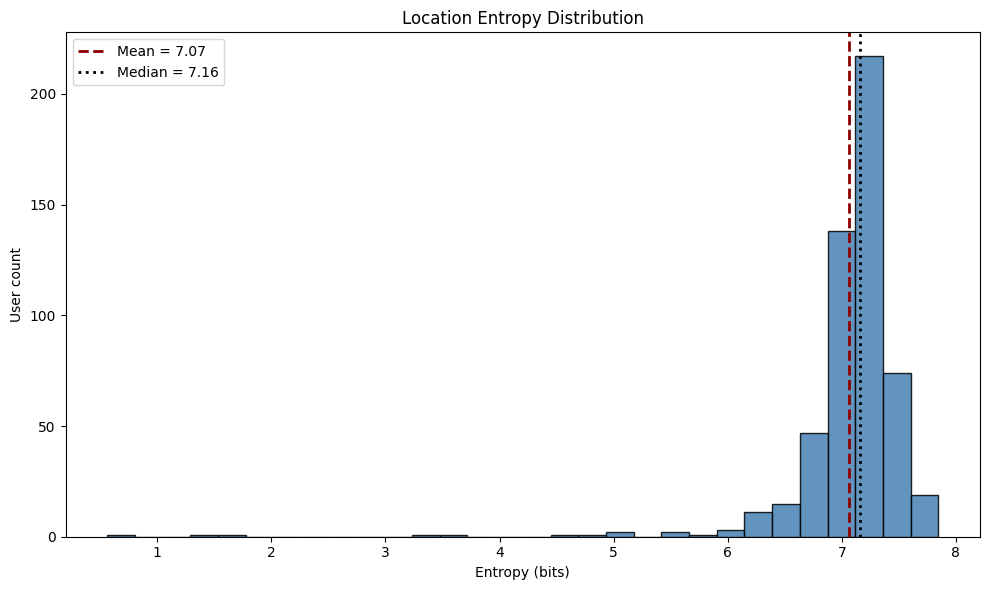

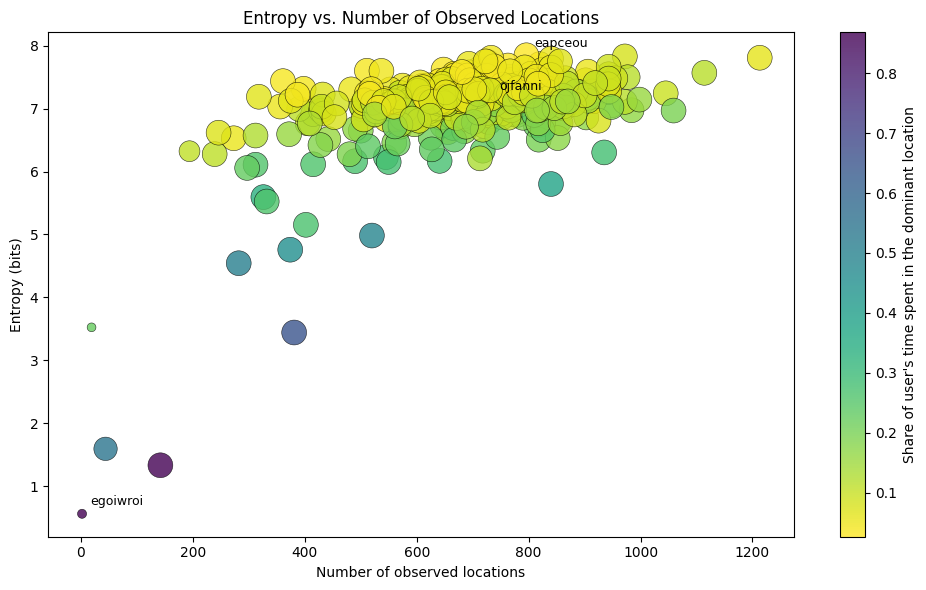

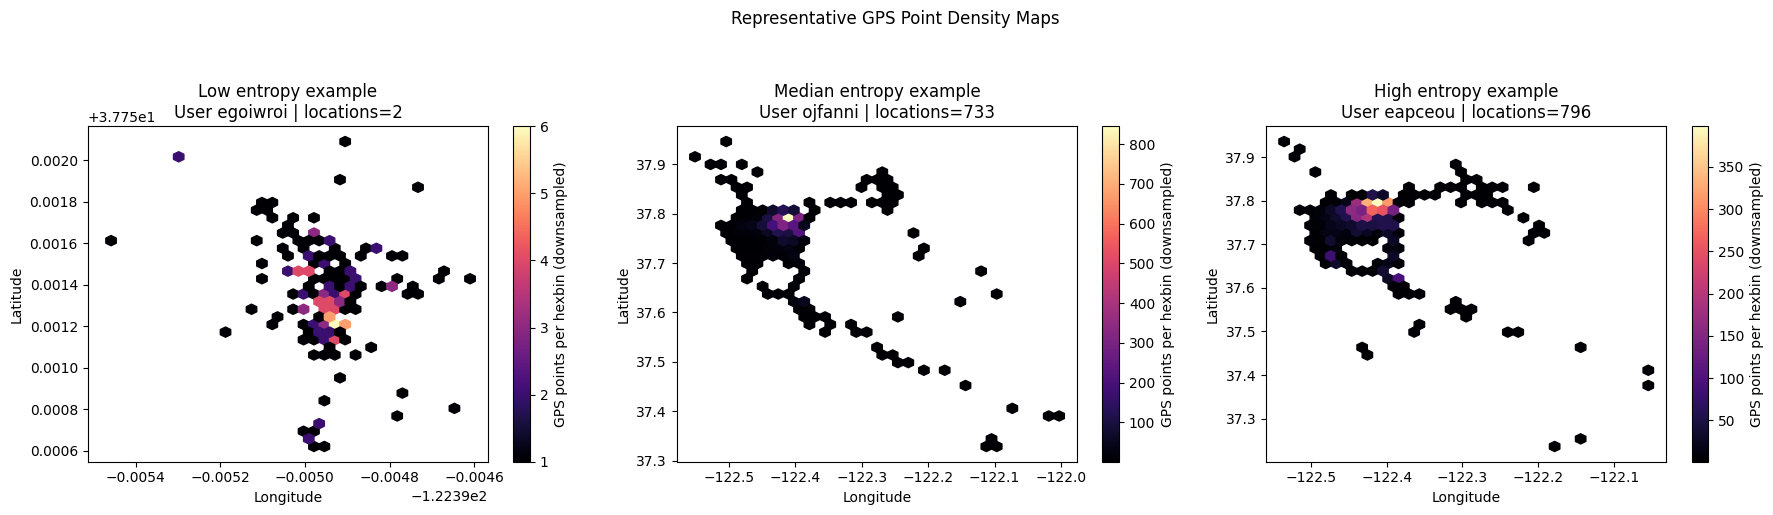

,segment,user_count,avg_entropy,avg_num_locations,avg_top_location_share,avg_observed_hours
0,Low entropy,179,6.63,622.5,0.158,353.9
1,Medium entropy,179,7.16,700.5,0.086,425.0
2,High entropy,178,7.41,743.7,0.066,439.0


Step 6 complete: render clearer explanatory visualizations
Representative users: egoiwroi, ojfanni, eapceou


In [63]:
# Step 6 output: display all graphs and the summary at the end.
for figure in step6_matplotlib_figures:
    display(figure)

for plotly_figure in step6_plotly_figures:
    display(plotly_figure)

if segment_summary_df is not None:
    display(segment_summary_df)

print("Step 6 complete: render clearer explanatory visualizations")
print(f"Representative users: {', '.join(representative_user_ids) or 'none'}")

## Ranked Results Preview

This table is the compact analytical output of the pipeline. It makes it easy to inspect the highest-entropy users directly, confirm that the ranking is sensible, and compare the summary statistics used in the plots.

In [64]:
preview_rows = [
    {"rank": rank, **row}
    for rank, row in enumerate(rows_sorted, start=1)
]

display(pd.DataFrame(preview_rows).head(10))

,rank,user_id,entropy,normalized_entropy,num_locations,top_location_share,total_observed_seconds,transitions_used,transitions_skipped
0,1,eapceou,7.846836,0.814272,796,0.026297,1614358,27524,14
1,2,aducrisi,7.828749,0.788806,972,0.081182,1398883,21860,25
2,3,oogchyog,7.807003,0.762078,1213,0.060082,1732404,23003,16
3,4,ivheoo,7.806937,0.820257,733,0.048636,1675215,23877,12
4,5,iorjtwav,7.794611,0.802390,840,0.049857,1636067,25651,17
5,6,urfhod,7.750342,0.795603,856,0.067163,1614559,23489,12
6,7,ugifmav,7.749852,0.815958,723,0.049653,1441218,17545,19
7,8,ecforj,7.745139,0.814950,726,0.067196,1778864,22090,19
8,9,idlorra,7.711072,0.817136,693,0.054138,1465777,21760,12
9,10,adnerst,7.705997,0.796117,820,0.056883,1695566,25244,16


## Findings and Product Ideas

### Findings

The entropy results suggest that users in this sample do not all behave the same way. Some users are strongly concentrated in a small number of locations with a high top-location share, which is consistent with routine movement patterns. Others distribute their observed time across many more locations and show much higher entropy, indicating broader or less predictable mobility.

The most useful pattern in the notebook is the combination of the entropy scatter, the representative GPS point density maps, and the single-day 3D trajectories. Together, they show that high entropy is not only about visiting many places, but also about how evenly time is distributed across those places and across the day. This is why the top-location share is helpful alongside entropy: two users may visit many locations, but the one dominated by a single location still behaves more routinely.

### Product Ideas

- **Mobility segmentation:** Use low-, medium-, and high-entropy segments to build user archetypes such as highly routine users versus highly exploratory users.
- **Dispatch or demand planning:** In a transport setting, low-entropy users may indicate repeated corridor usage or habitual zones, while high-entropy users may indicate broader service coverage needs.
- **Personalization and anomaly detection:** A user's historical entropy can become a behavioral baseline. Sudden shifts toward much lower or much higher entropy may signal operational changes, unusual activity, or opportunities for intervention.

### Limitations

This notebook uses grid-based discretization rather than map-matched road segments or POIs, so the results depend on the chosen spatial resolution. It also relies on observed trace coverage, which means long missing intervals must be filtered carefully to avoid overstating dwell time. Those choices are reasonable for an interview assignment, but they would likely be refined in production.

## Notes

- Set `LIMIT_USERS = None` in the configuration cell to run the full dataset.
- Tune `GRID_SIZE_DEGREES` to make locations coarser or finer.
- Tune `MAX_GAP_SECONDS` to control how long inactive intervals are counted.
- Tune `TRAJECTORY_POINT_LIMIT` if the trajectory plots look too dense or too sparse.